In [1]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.cluster.hierarchy import dendrogram, fcluster, linkage

from sklearn.datasets import load_wine

from sklearn.preprocessing import StandardScaler


In [2]:
wine = load_wine(as_frame=True)
X = wine["data"]
y = wine["target"]

In [3]:
X

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


Text(0, 0.5, 'Color Intensity')

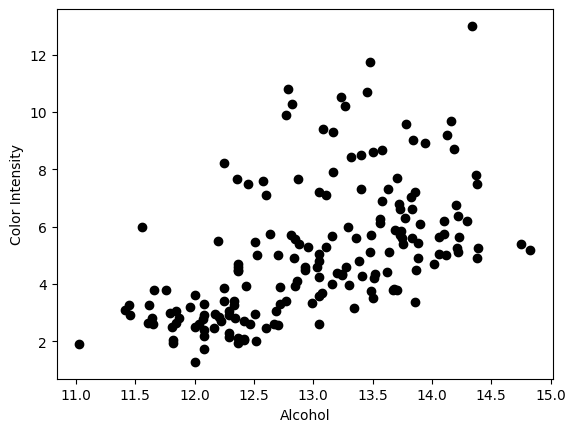

In [4]:
Xsub = X[["alcohol","color_intensity"]]

plt.scatter(*Xsub.values.T,marker="o",c="black")
plt.xlabel("Alcohol")
plt.ylabel("Color Intensity")

In [5]:
scaler = StandardScaler()
Xs = scaler.fit_transform(Xsub)

Text(0, 0.5, 'Color Intensity')

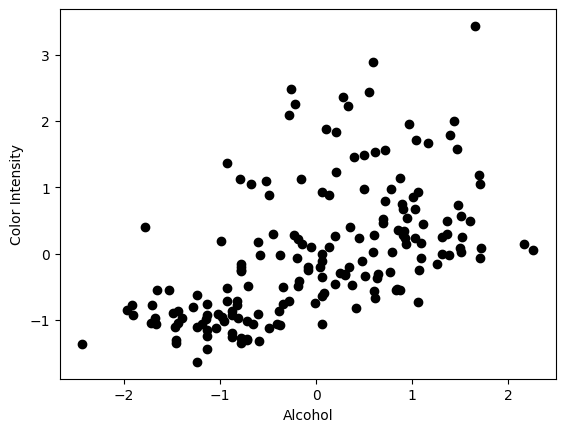

In [6]:
plt.scatter(*Xs.T,marker="o",c="black")
plt.xlabel("Alcohol")
plt.ylabel("Color Intensity")

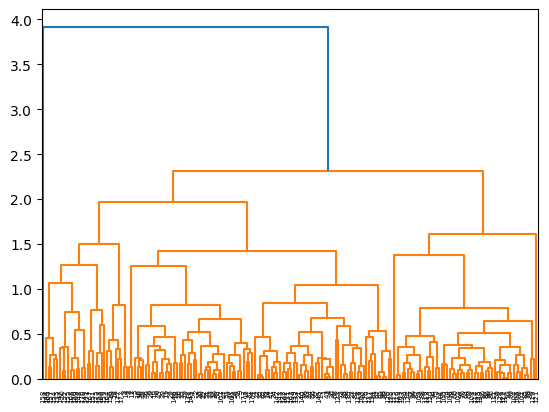

In [7]:
link = linkage(Xs,method="average",optimal_ordering=True)
dnd = dendrogram(link)
plt.show()

In [8]:
labels = fcluster(link,t=1.7,criterion="distance")

Text(0, 0.5, 'Color Intensity')

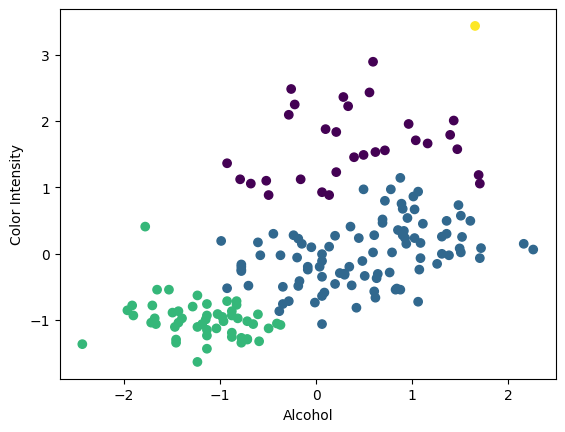

In [9]:
plt.scatter(*Xs.T,marker="o",c=labels)
plt.xlabel("Alcohol")
plt.ylabel("Color Intensity")

Text(0, 0.5, 'Color Intensity')

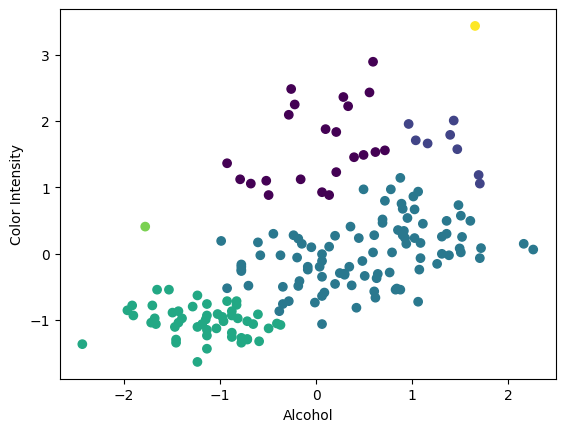

In [10]:
labels = fcluster(link,t=1.5,criterion="distance")
Xs = scaler.fit_transform(Xsub)
plt.scatter(*Xs.T,marker="o",c=labels)
plt.xlabel("Alcohol")
plt.ylabel("Color Intensity")

In [11]:
from sklearn.metrics import adjusted_rand_score

In [12]:
adjusted_rand_score(labels_pred=labels,labels_true=y)

0.35842642995017365

# Distintos enlaces

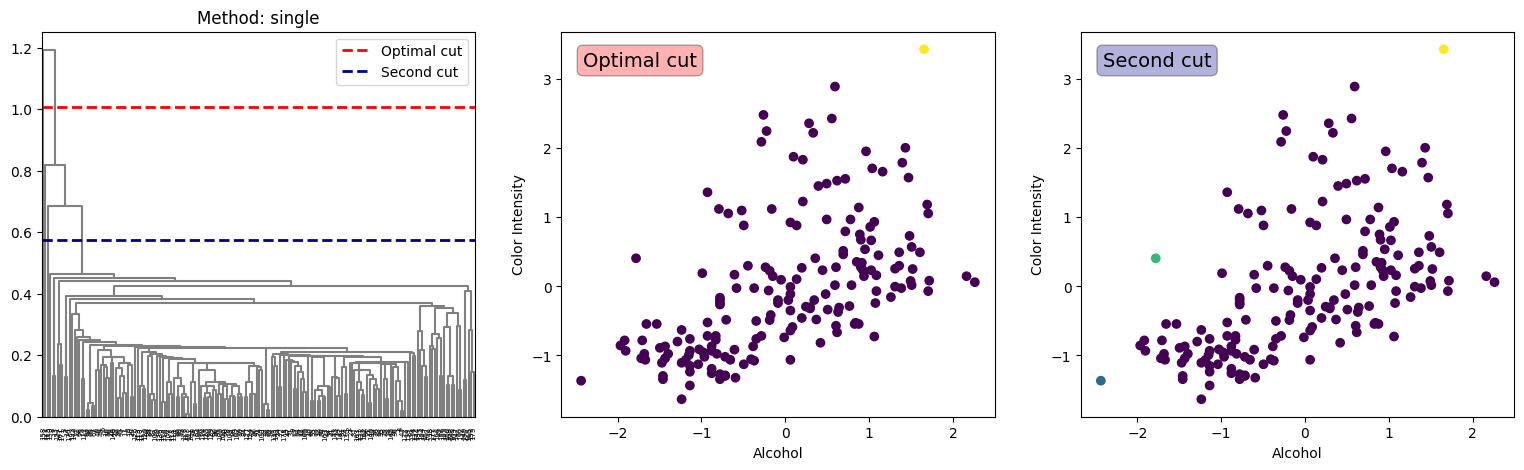

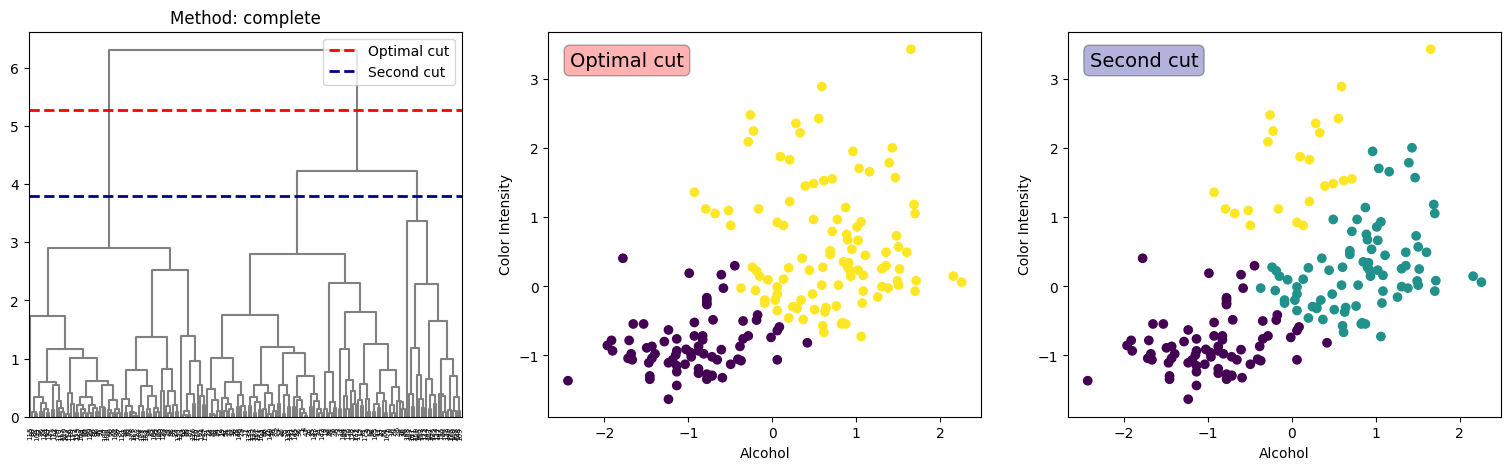

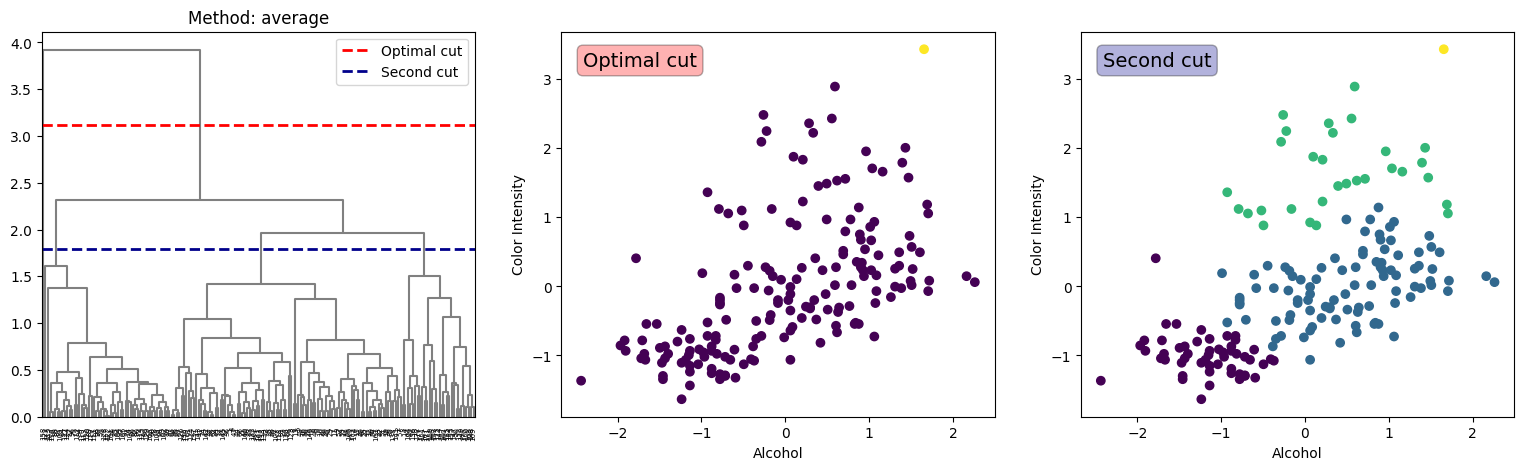

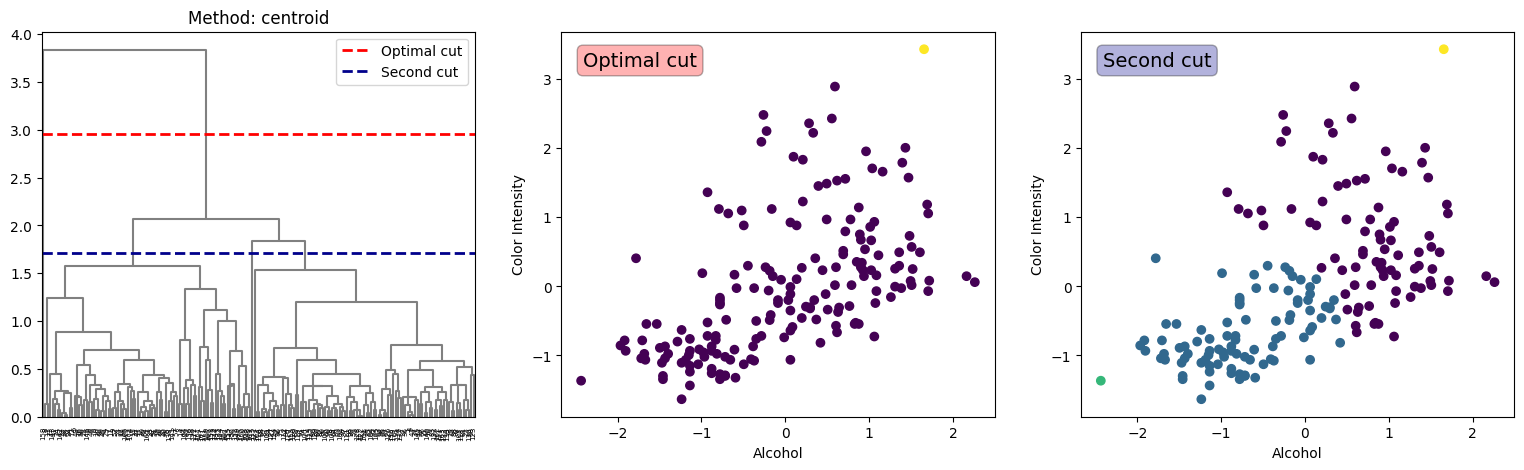

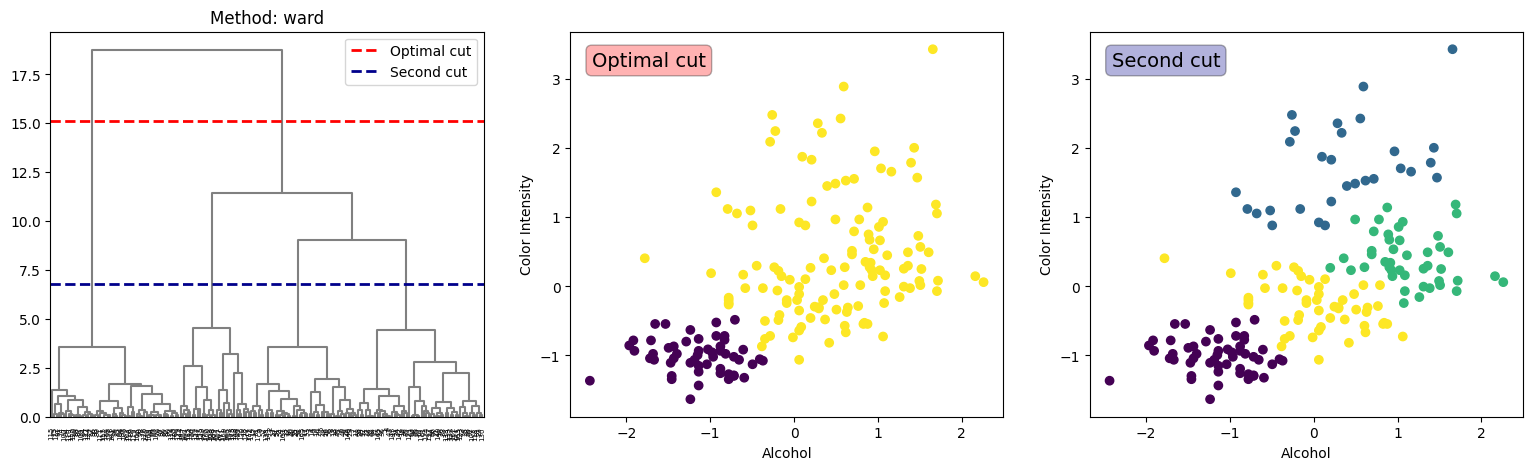

In [13]:
methods = ["single","complete","average","centroid","ward"]

for m in methods:
    link = linkage(Xs,method=m)
    distances = link[:,2]
    diffs = np.diff(distances)
    sdiffs_arg = np.argsort(diffs)
    amax = sdiffs_arg[-1]
    asecond = sdiffs_arg[-2]
    distance_cut = (distances[amax] + distances[amax + 1])/2
    distance_cut_2 = (distances[asecond] + distances[asecond+1])/2
    labels = fcluster(link,t=distance_cut,criterion="distance")
    labels_2 = fcluster(link,t=distance_cut_2,criterion="distance")
    plt.figure(figsize=(19,5))
    plt.subplot(131)
    dnd = dendrogram(link,leaf_rotation=90.,link_color_func=lambda x: "gray")
    plt.axhline(y=distance_cut, c='r', ls='--', lw=2, label='Optimal cut')
    plt.axhline(y=distance_cut_2, c='darkblue', ls='--', lw=2, label='Second cut')
    plt.title(f"Method: {m}")
    plt.legend()
    plt.subplot(132)
    plt.scatter(*Xs.T,c=labels)
    plt.xlabel("Alcohol")
    plt.ylabel("Color Intensity")
    ax = plt.gca()
    ax.text(
        0.05, 0.95, "Optimal cut",
        transform=ax.transAxes, # ¡Esto es clave!
        fontsize=14,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='red', alpha=0.3)
    )
    plt.subplot(133)
    plt.scatter(*Xs.T,c=labels_2)
    plt.xlabel("Alcohol")
    plt.ylabel("Color Intensity")
    ax = plt.gca()
    ax.text(
        0.05, 0.95, "Second cut",
        transform=ax.transAxes, # ¡Esto es clave!
        fontsize=14,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='darkblue', alpha=0.3)
    )
    plt.show()

# Datos reales

Text(0, 0.5, 'Color Intensity')

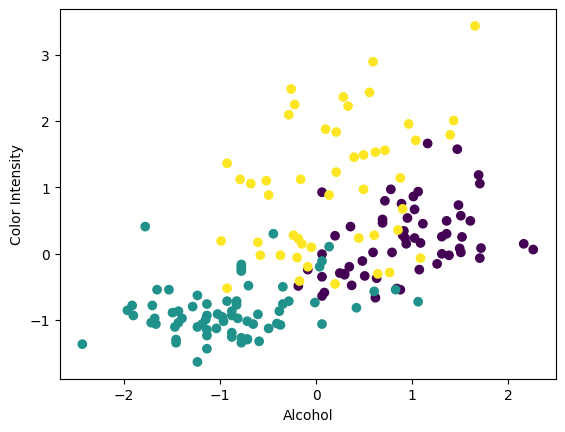

In [14]:
plt.scatter(*Xs.T,marker="o",c=y)
plt.xlabel("Alcohol")
plt.ylabel("Color Intensity")

## Todas las variables

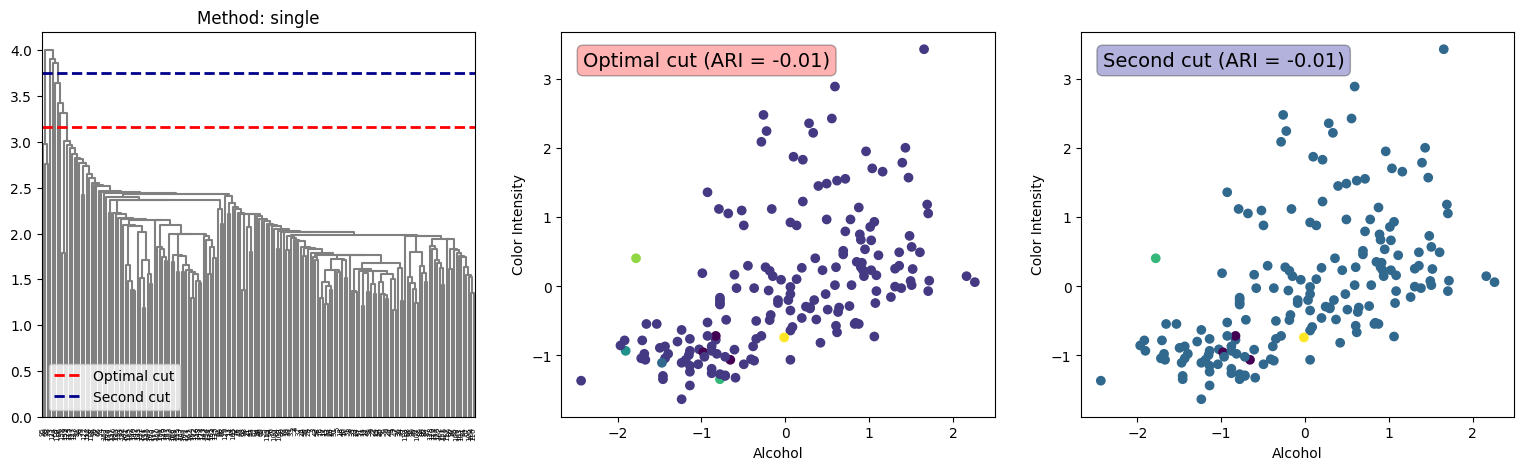

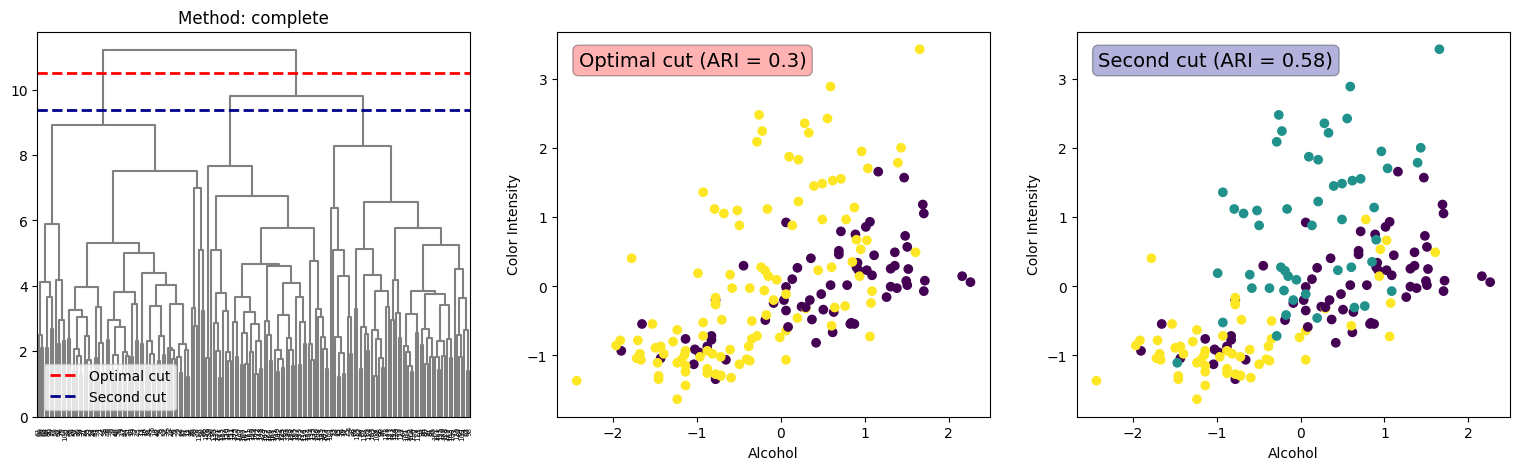

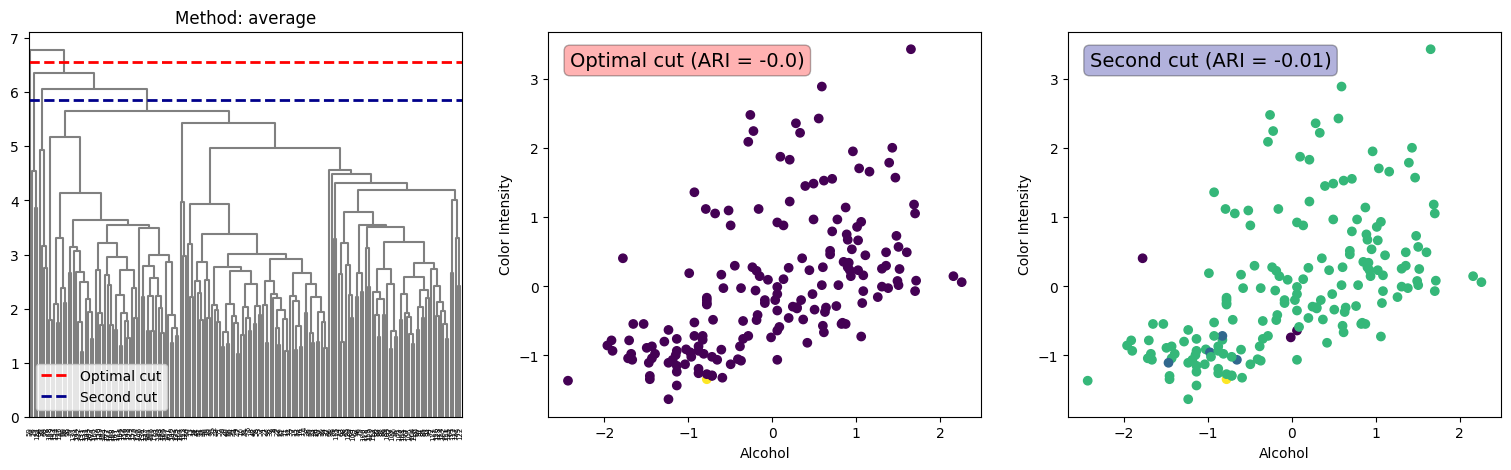

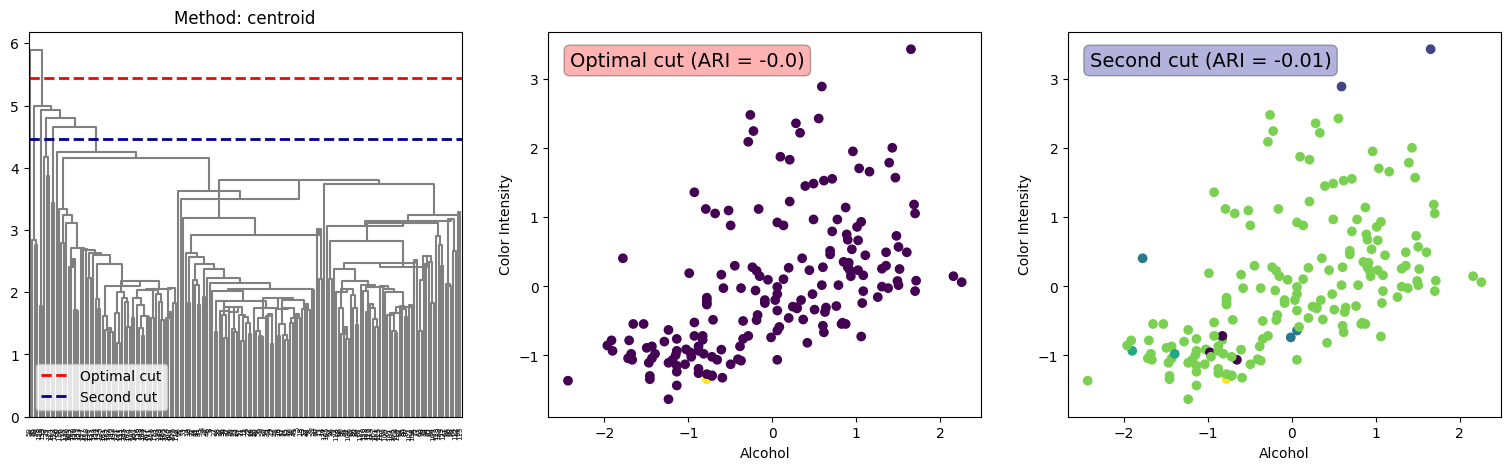

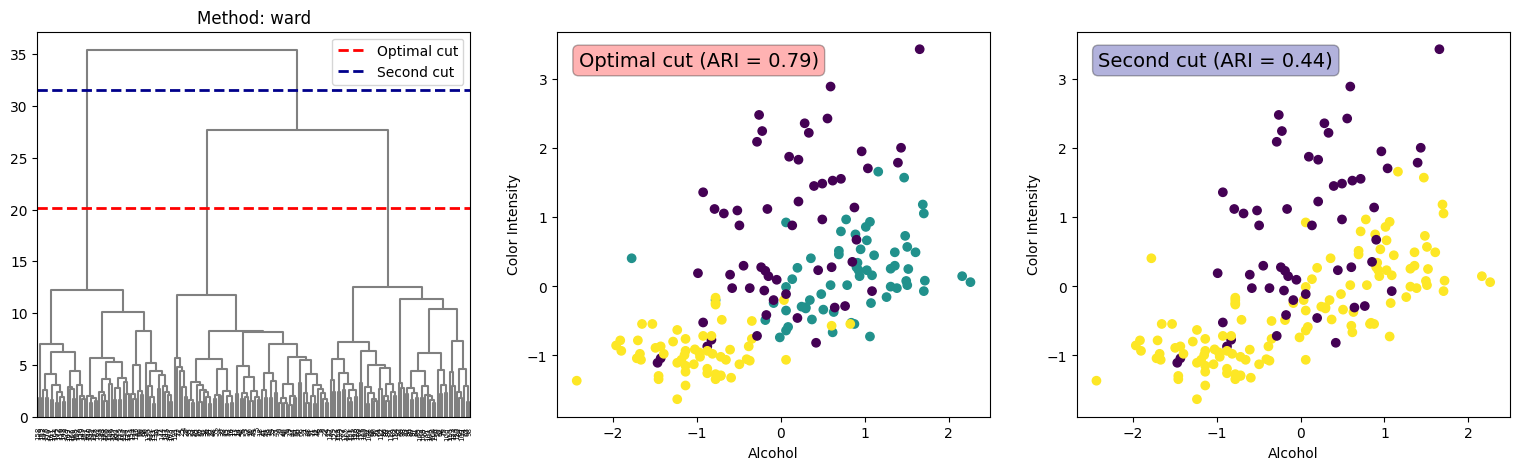

In [15]:
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

for m in methods:
    link = linkage(Xs,method=m)
    distances = link[:,2]
    diffs = np.diff(distances)
    sdiffs_arg = np.argsort(diffs)
    amax = sdiffs_arg[-1]
    asecond = sdiffs_arg[-2]
    distance_cut = (distances[amax] + distances[amax + 1])/2
    distance_cut_2 = (distances[asecond] + distances[asecond+1])/2
    labels = fcluster(link,t=distance_cut,criterion="distance")
    labels_2 = fcluster(link,t=distance_cut_2,criterion="distance")
    ari = adjusted_rand_score(labels_pred=labels,labels_true=y)
    ari_2 = adjusted_rand_score(labels_pred=labels_2,labels_true=y)
    plt.figure(figsize=(19,5))
    plt.subplot(131)
    dnd = dendrogram(link,leaf_rotation=90.,link_color_func=lambda x: "gray")
    plt.axhline(y=distance_cut, c='r', ls='--', lw=2, label='Optimal cut')
    plt.axhline(y=distance_cut_2, c='darkblue', ls='--', lw=2, label='Second cut')
    plt.title(f"Method: {m}")
    plt.legend()
    plt.subplot(132)
    plt.scatter(*Xs[:,[0,9]].T,c=labels)
    plt.xlabel("Alcohol")
    plt.ylabel("Color Intensity")
    ax = plt.gca()
    ax.text(
        0.05, 0.95, f"Optimal cut (ARI = {round(ari,2)})",
        transform=ax.transAxes, # ¡Esto es clave!
        fontsize=14,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='red', alpha=0.3)
    )
    plt.subplot(133)
    plt.scatter(*Xs[:,[0,9]].T,c=labels_2)
    plt.xlabel("Alcohol")
    plt.ylabel("Color Intensity")
    ax = plt.gca()
    ax.text(
        0.05, 0.95, f"Second cut (ARI = {round(ari_2,2)})",
        transform=ax.transAxes, # ¡Esto es clave!
        fontsize=14,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='darkblue', alpha=0.3)
    )
    plt.show()

# Quitamos outliers

In [16]:
from sklearn.preprocessing import QuantileTransformer

In [17]:
qtransformer = QuantileTransformer(n_quantiles=10)
Xt = qtransformer.fit_transform(X)

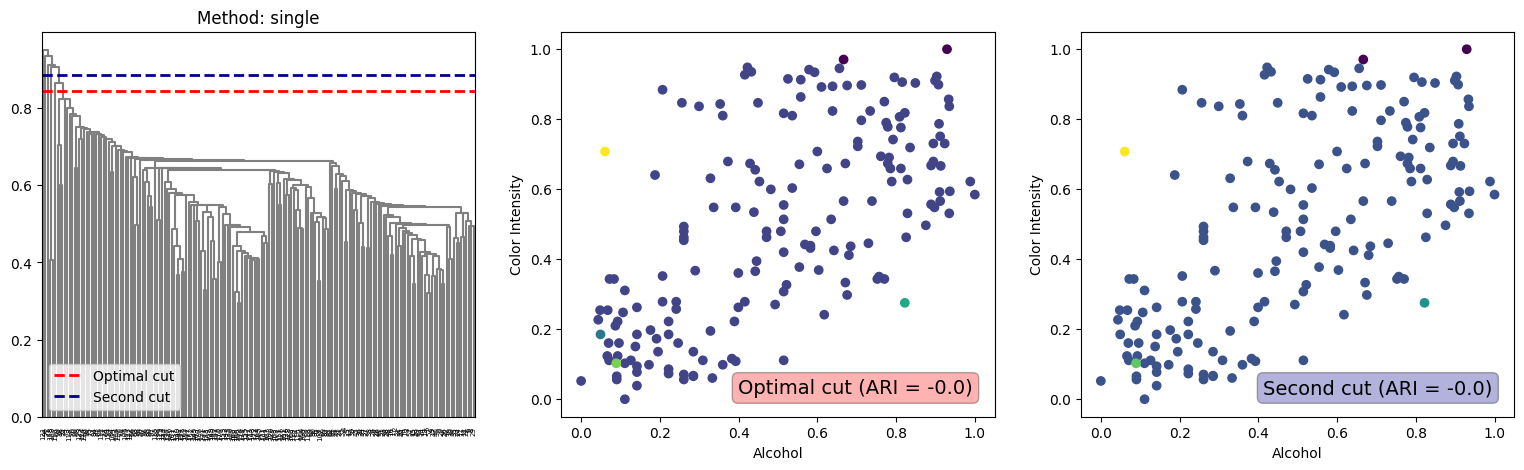

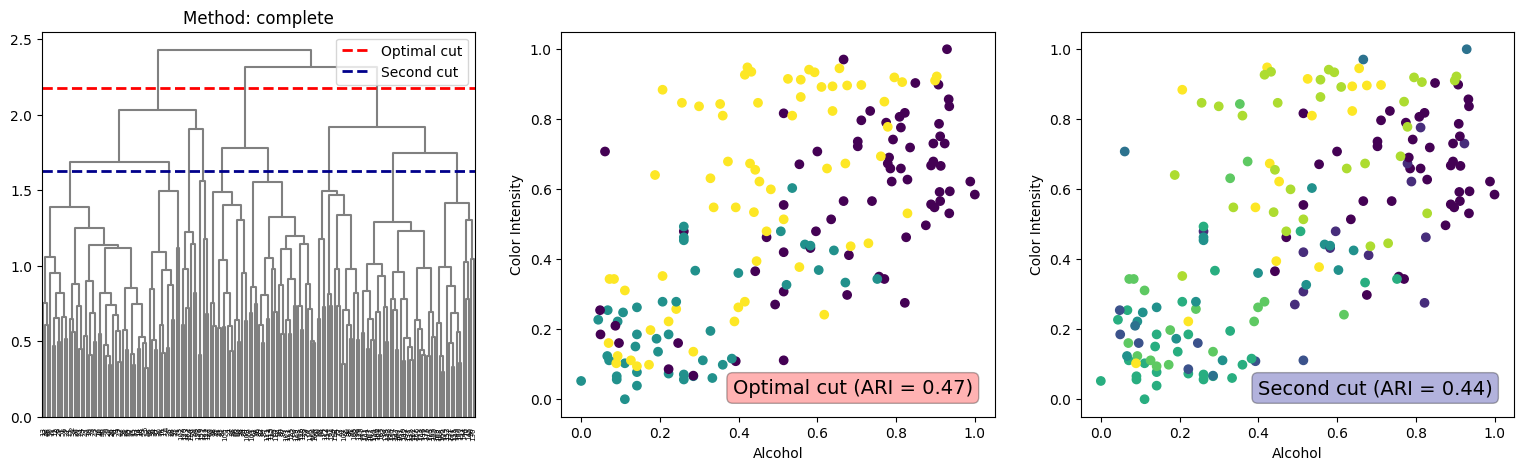

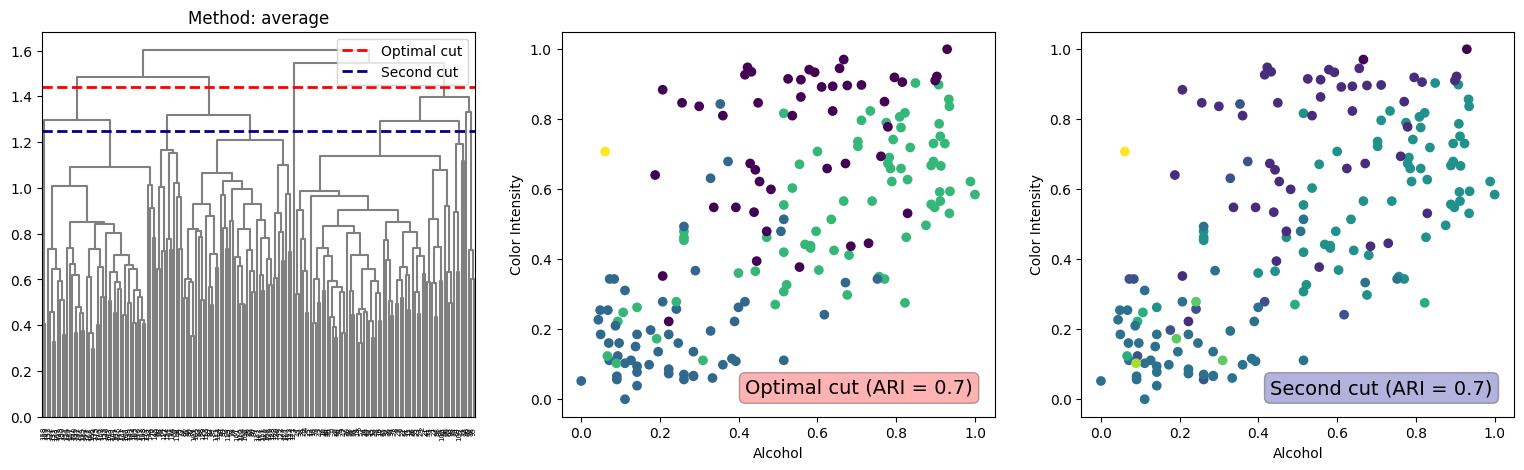

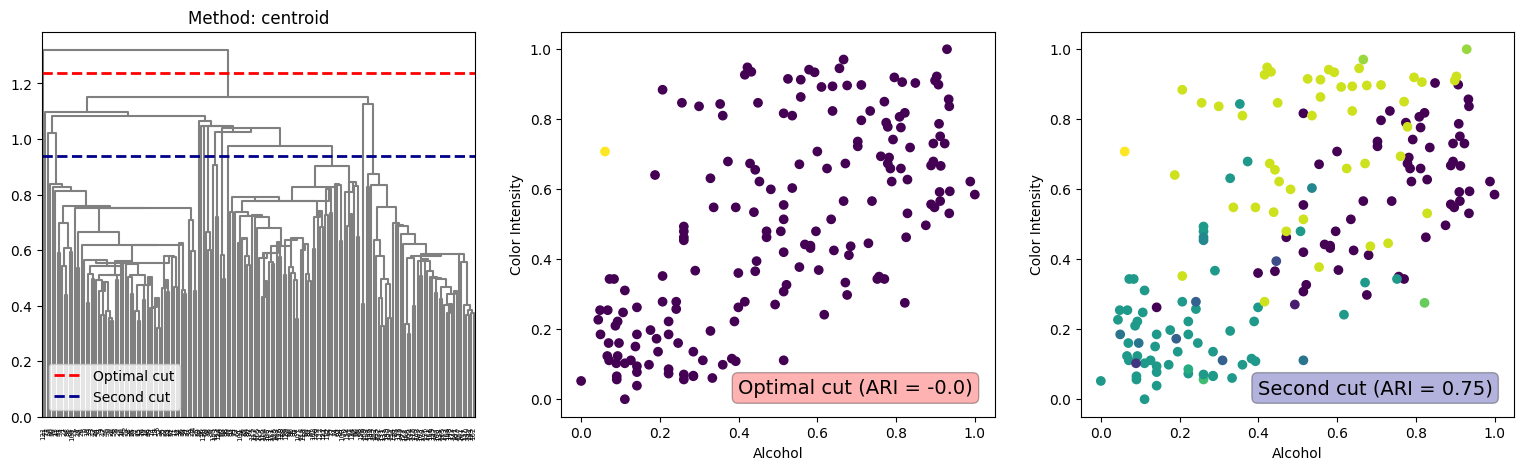

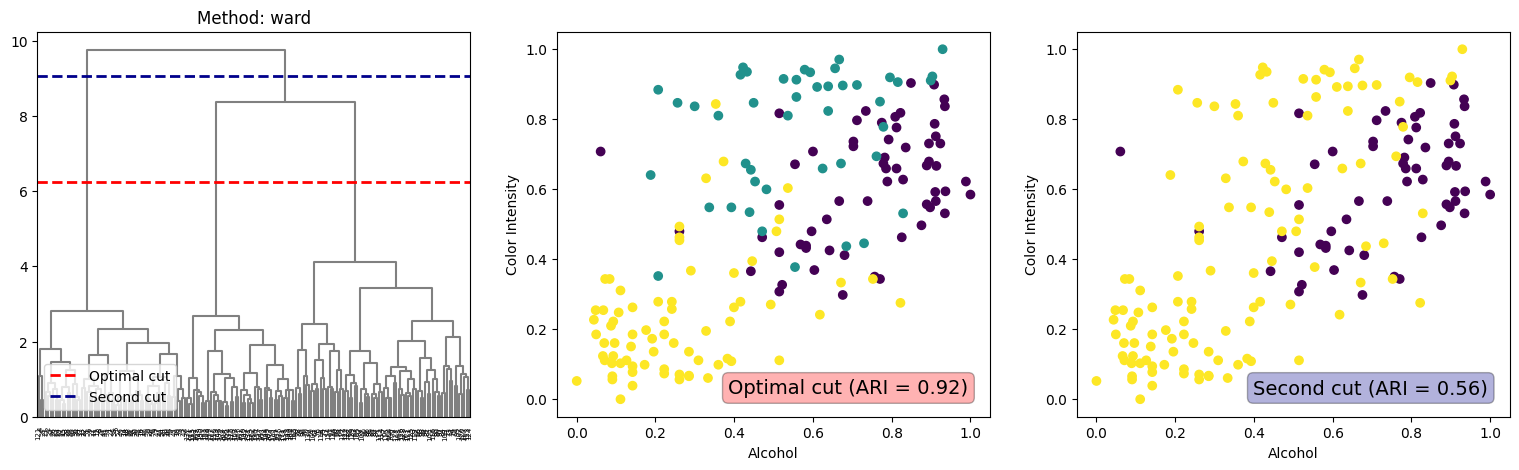

In [18]:
for m in methods:
    link = linkage(Xt,method=m)
    distances = link[:,2]
    diffs = np.diff(distances)
    sdiffs_arg = np.argsort(diffs)
    amax = sdiffs_arg[-1]
    asecond = sdiffs_arg[-2]
    distance_cut = (distances[amax] + distances[amax + 1])/2
    distance_cut_2 = (distances[asecond] + distances[asecond+1])/2
    labels = fcluster(link,t=distance_cut,criterion="distance")
    labels_2 = fcluster(link,t=distance_cut_2,criterion="distance")
    ari = adjusted_rand_score(labels_pred=labels,labels_true=y)
    ari_2 = adjusted_rand_score(labels_pred=labels_2,labels_true=y)
    plt.figure(figsize=(19,5))
    plt.subplot(131)
    dnd = dendrogram(link,leaf_rotation=90.,link_color_func=lambda x: "gray")
    plt.axhline(y=distance_cut, c='r', ls='--', lw=2, label='Optimal cut')
    plt.axhline(y=distance_cut_2, c='darkblue', ls='--', lw=2, label='Second cut')
    plt.title(f"Method: {m}")
    plt.legend()
    plt.subplot(132)
    plt.scatter(*Xt[:,[0,9]].T,c=labels)
    plt.xlabel("Alcohol")
    plt.ylabel("Color Intensity")
    ax = plt.gca()
    ax.text(
        0.95, 0.05, f"Optimal cut (ARI = {round(ari,2)})",
        transform=ax.transAxes, # ¡Esto es clave!
        fontsize=14,
        verticalalignment='bottom',
        horizontalalignment="right",
        bbox=dict(boxstyle='round', facecolor='red', alpha=0.3)
    )
    plt.subplot(133)
    plt.scatter(*Xt[:,[0,9]].T,c=labels_2)
    plt.xlabel("Alcohol")
    plt.ylabel("Color Intensity")
    ax = plt.gca()
    ax.text(
        0.95, 0.05, f"Second cut (ARI = {round(ari_2,2)})",
        transform=ax.transAxes, # ¡Esto es clave!
        fontsize=14,
        verticalalignment='bottom',
        horizontalalignment="right",
        bbox=dict(boxstyle='round', facecolor='darkblue', alpha=0.3)
    )
    plt.show()

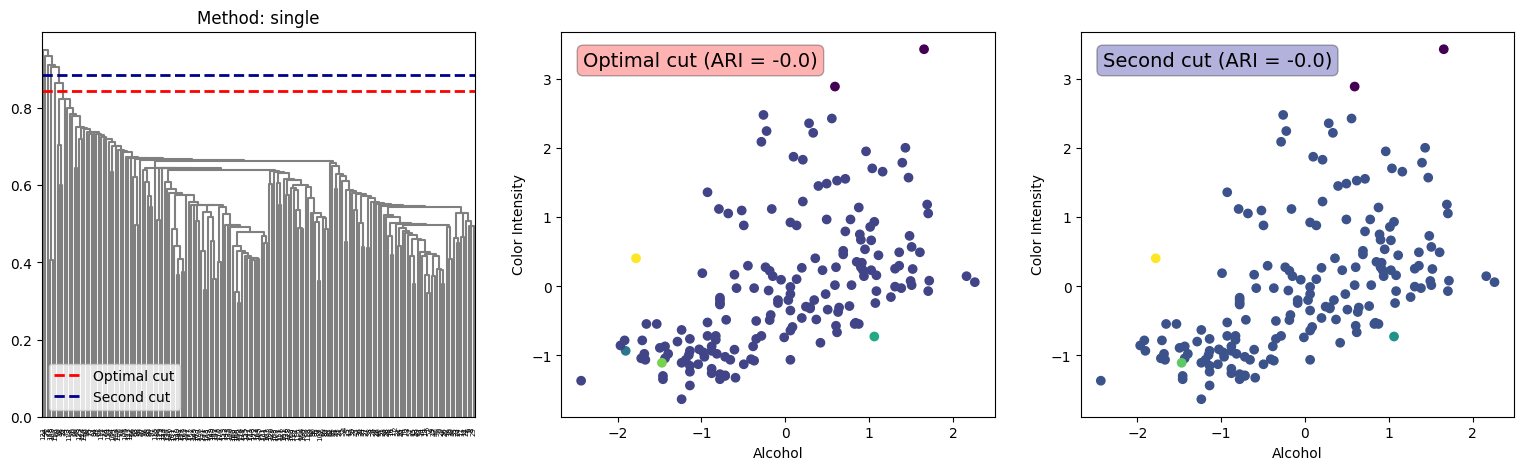

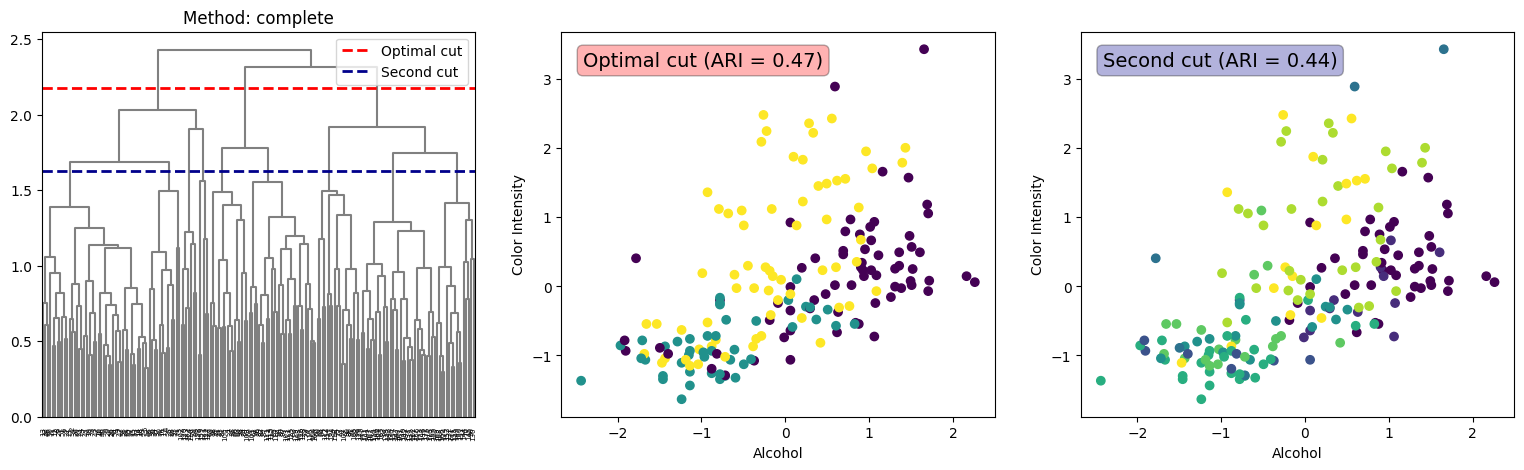

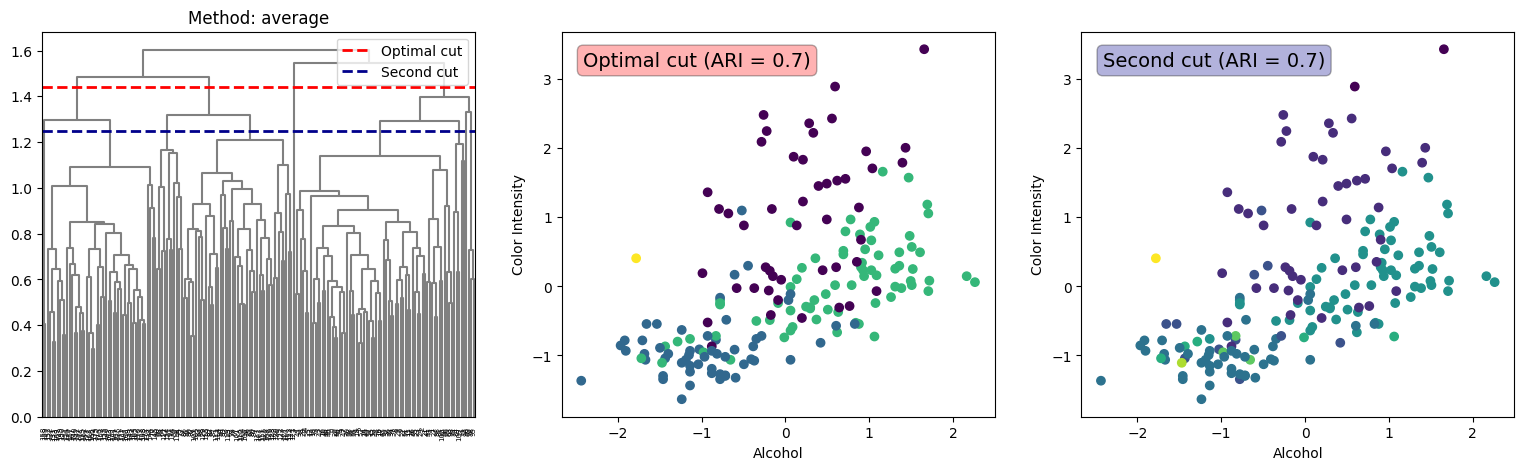

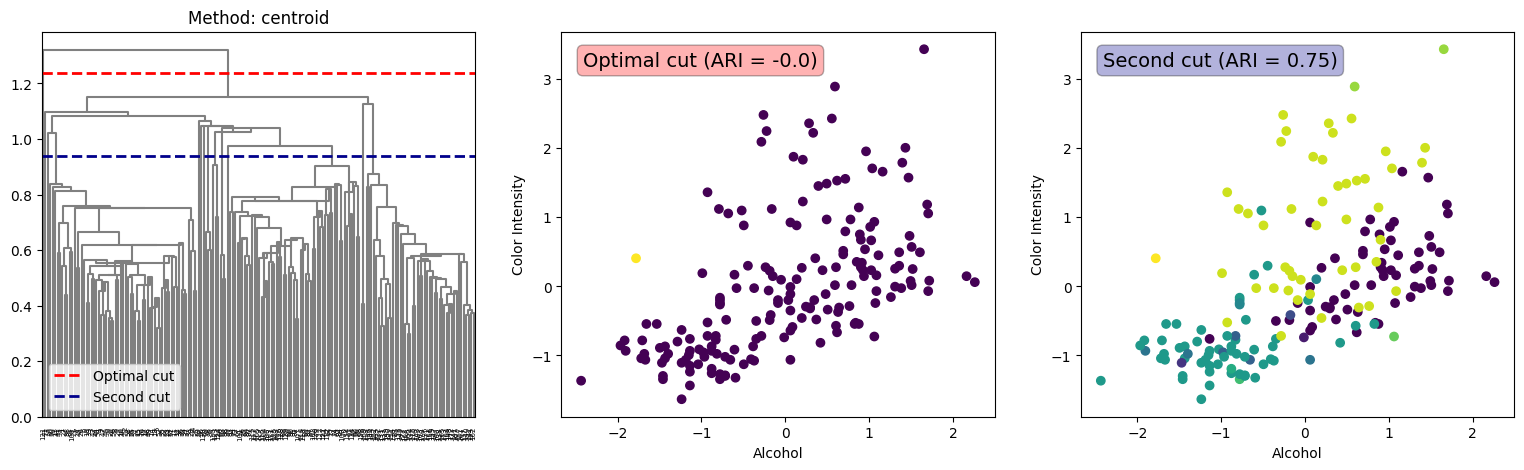

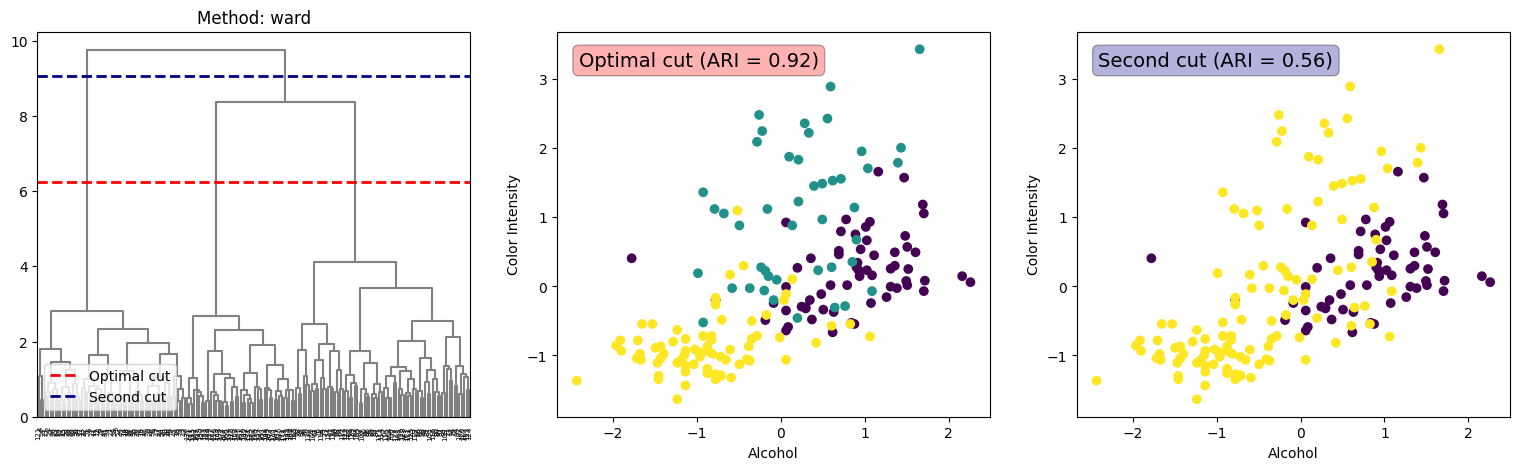

In [19]:
for m in methods:
    link = linkage(Xt,method=m)
    distances = link[:,2]
    diffs = np.diff(distances)
    sdiffs_arg = np.argsort(diffs)
    amax = sdiffs_arg[-1]
    asecond = sdiffs_arg[-2]
    distance_cut = (distances[amax] + distances[amax + 1])/2
    distance_cut_2 = (distances[asecond] + distances[asecond+1])/2
    labels = fcluster(link,t=distance_cut,criterion="distance")
    labels_2 = fcluster(link,t=distance_cut_2,criterion="distance")
    ari = adjusted_rand_score(labels_pred=labels,labels_true=y)
    ari_2 = adjusted_rand_score(labels_pred=labels_2,labels_true=y)
    plt.figure(figsize=(19,5))
    plt.subplot(131)
    dnd = dendrogram(link,leaf_rotation=90.,link_color_func=lambda x: "gray")
    plt.axhline(y=distance_cut, c='r', ls='--', lw=2, label='Optimal cut')
    plt.axhline(y=distance_cut_2, c='darkblue', ls='--', lw=2, label='Second cut')
    plt.title(f"Method: {m}")
    plt.legend()
    plt.subplot(132)
    plt.scatter(*Xs[:,[0,9]].T,c=labels)
    plt.xlabel("Alcohol")
    plt.ylabel("Color Intensity")
    ax = plt.gca()
    ax.text(
        0.05, 0.95, f"Optimal cut (ARI = {round(ari,2)})",
        transform=ax.transAxes, # ¡Esto es clave!
        fontsize=14,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='red', alpha=0.3)
    )
    plt.subplot(133)
    plt.scatter(*Xs[:,[0,9]].T,c=labels_2)
    plt.xlabel("Alcohol")
    plt.ylabel("Color Intensity")
    ax = plt.gca()
    ax.text(
        0.05, 0.95, f"Second cut (ARI = {round(ari_2,2)})",
        transform=ax.transAxes, # ¡Esto es clave!
        fontsize=14,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='darkblue', alpha=0.3)
    )
    plt.show()